# THỰC HÀNH 1 & 2: Làm sạch dữ liệu Xét tuyển Đại học
**Tài liệu tham khảo:** Thực hành 1 (Numpy & Pandas) + Thực hành 2 (TensorFlow cơ bản)

## Mô tả dataset `dulieuxettuyendaihoc.csv`
- **100 hồ sơ** sinh viên xét tuyển đại học
- **6 học kỳ** (T1–T6), mỗi học kỳ có **8 môn**: T, L, H, S, V, X, D, N → 48 cột điểm
- **GT**: Giới tính (M/F) | **DT**: Dân tộc (hầu hết NaN) | **KV**: Khu vực (1/2/2NT)
- **DH1, DH2, DH3**: Điểm xét tuyển 3 nguyện vọng | **KT**: Kết quả (A/A1/B/C/D1)

In [1]:
# ============================================================
# BƯỚC 1: NẠP THƯ VIỆN (Numpy + Pandas theo tài liệu)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

print('NumPy version :', np.__version__)
print('Pandas version:', pd.__version__)
print('TF version    :', tf.__version__)

NumPy version : 2.0.2
Pandas version: 2.2.2
TF version    : 2.20.0


In [2]:
# ============================================================
# BƯỚC 2: ĐỌC DỮ LIỆU TỪ CSV (Pandas - mục 7.2)
# ============================================================
# Upload file lên Colab trước khi chạy cell này
from google.colab import files
uploaded = files.upload()   # chọn file dulieuxettuyendaihoc.csv

import io
df_raw = pd.read_csv(io.BytesIO(uploaded['dulieuxettuyendaihoc.csv']))
print('Shape:', df_raw.shape)
print('\n--- 5 dòng đầu tiên ---')
print(df_raw.head())

Saving dulieuxettuyendaihoc.csv to dulieuxettuyendaihoc.csv
Shape: (100, 56)

--- 5 dòng đầu tiên ---
   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...   X6   D6   N6  GT  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  6.6  7.6  5.9   F   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  6.6  6.1  4.4   M   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  7.9  8.1  4.6   M   
3    4  6.6  6.4  5.3  6.9  5.4  7.3  6.4  5.8  5.1  ...  7.1  7.3  7.4   M   
4    5  6.0  5.0  6.0  7.3  6.5  7.7  7.9  6.1  5.4  ...  6.1  7.5  7.2   M   

   DT   KV   DH1   DH2   DH3  KT  
0 NaN  2NT  3.25  3.25  4.50  A1  
1 NaN    1  6.00  4.00  3.50   C  
2 NaN    1  5.00  6.75  4.00   C  
3 NaN    1  4.25  4.25  5.25  D1  
4 NaN  2NT  4.25  4.50  5.00   A  

[5 rows x 56 columns]


In [3]:
# ============================================================
# BƯỚC 3: KHÁM PHÁ DỮ LIỆU BAN ĐẦU (EDA)
# ============================================================
print('=== Thông tin tổng quan ===')
df_raw.info()

print('\n=== Mô tả thống kê ===')
print(df_raw.describe())

print('\n=== Số lượng giá trị null theo cột ===')
null_counts = df_raw.isnull().sum()
print(null_counts[null_counts > 0])

print('\n=== Giá trị duy nhất cột phân loại ===')
for col in ['GT', 'KV', 'KT']:
    print(f'  {col}: {df_raw[col].unique()}')

=== Thông tin tổng quan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STT     100 non-null    int64  
 1   T1      100 non-null    float64
 2   L1      100 non-null    float64
 3   H1      100 non-null    float64
 4   S1      100 non-null    float64
 5   V1      100 non-null    float64
 6   X1      100 non-null    float64
 7   D1      100 non-null    float64
 8   N1      100 non-null    float64
 9   T2      100 non-null    float64
 10  L2      100 non-null    float64
 11  H2      100 non-null    float64
 12  S2      100 non-null    float64
 13  V2      100 non-null    float64
 14  X2      100 non-null    float64
 15  D2      100 non-null    float64
 16  N2      100 non-null    float64
 17  T3      100 non-null    float64
 18  L3      100 non-null    float64
 19  H3      100 non-null    float64
 20  S3      100 non-null    float64
 21  V3      100 

In [4]:
# ============================================================
# BƯỚC 4: XÁC ĐỊNH CÁC CỘT ĐIỂM (Numpy array - mục 3)
# ============================================================
# 48 cột điểm: T1..T6, L1..L6, H1..H6, S1..S6, V1..V6, X1..X6, D1..D6, N1..N6
score_cols = [f'{mon}{hk}' for hk in range(1,7) for mon in ['T','L','H','S','V','X','D','N']]
cat_cols   = ['GT', 'KV', 'KT']
target_cols = ['DH1', 'DH2', 'DH3']

print(f'Số cột điểm  : {len(score_cols)} cột')
print(f'Cột phân loại: {cat_cols}')
print(f'Cột mục tiêu : {target_cols}')
print(f'Cột ẩn (DT)  : DT — {df_raw["DT"].notna().sum()} / {len(df_raw)} có giá trị')

# Chuyển sang numpy array để kiểm tra (theo tài liệu Numpy)
score_np = df_raw[score_cols].to_numpy()
print(f'\nNumpyarray điểm shape: {score_np.shape}')
print(f'Min điểm: {np.nanmin(score_np):.2f} | Max điểm: {np.nanmax(score_np):.2f}')

Số cột điểm  : 48 cột
Cột phân loại: ['GT', 'KV', 'KT']
Cột mục tiêu : ['DH1', 'DH2', 'DH3']
Cột ẩn (DT)  : DT — 3 / 100 có giá trị

Numpyarray điểm shape: (100, 48)
Min điểm: 1.80 | Max điểm: 9.80


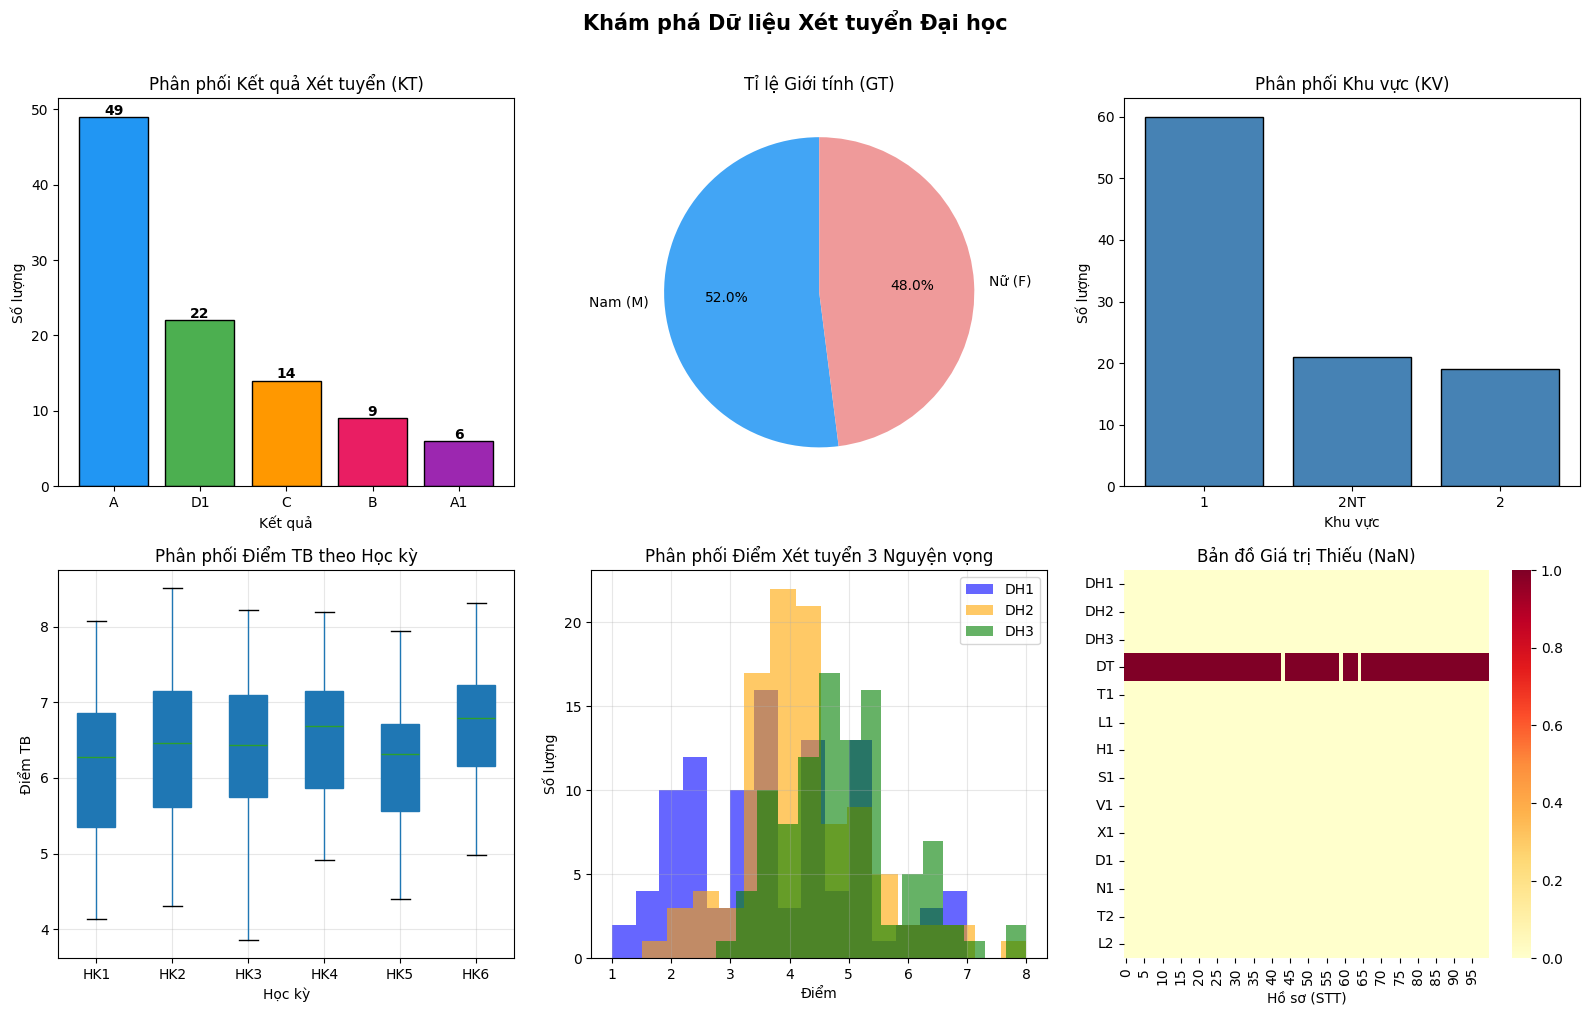

In [5]:
# ============================================================
# BƯỚC 5: TRỰC QUAN HÓA DỮ LIỆU (Matplotlib)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 5.1 Phân phối kết quả xét tuyển (KT)
kt_counts = df_raw['KT'].value_counts()
axes[0,0].bar(kt_counts.index, kt_counts.values,
              color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'], edgecolor='black')
for i,(v) in enumerate(kt_counts.values):
    axes[0,0].text(i, v+0.3, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Phân phối Kết quả Xét tuyển (KT)', fontsize=12)
axes[0,0].set_xlabel('Kết quả'); axes[0,0].set_ylabel('Số lượng')

# 5.2 Phân phối giới tính
gt_counts = df_raw['GT'].value_counts()
axes[0,1].pie(gt_counts.values, labels=['Nam (M)','Nữ (F)'],
              autopct='%1.1f%%', colors=['#42A5F5','#EF9A9A'], startangle=90)
axes[0,1].set_title('Tỉ lệ Giới tính (GT)', fontsize=12)

# 5.3 Phân phối khu vực
kv_counts = df_raw['KV'].value_counts()
axes[0,2].bar(kv_counts.index, kv_counts.values,
              color='steelblue', edgecolor='black')
axes[0,2].set_title('Phân phối Khu vực (KV)', fontsize=12)
axes[0,2].set_xlabel('Khu vực'); axes[0,2].set_ylabel('Số lượng')

# 5.4 Phân phối điểm trung bình học kỳ
semester_means = []
for hk in range(1,7):
    cols_hk = [f'{m}{hk}' for m in ['T','L','H','S','V','X','D','N']]
    semester_means.append(df_raw[cols_hk].mean(axis=1))

df_sem = pd.DataFrame({f'HK{i+1}': semester_means[i] for i in range(6)})
df_sem.boxplot(ax=axes[1,0], patch_artist=True)
axes[1,0].set_title('Phân phối Điểm TB theo Học kỳ', fontsize=12)
axes[1,0].set_xlabel('Học kỳ'); axes[1,0].set_ylabel('Điểm TB')
axes[1,0].grid(True, alpha=0.3)

# 5.5 Phân phối điểm xét tuyển DH1, DH2, DH3
axes[1,1].hist(df_raw['DH1'].dropna(), bins=15, alpha=0.6, label='DH1', color='blue')
axes[1,1].hist(df_raw['DH2'].dropna(), bins=15, alpha=0.6, label='DH2', color='orange')
axes[1,1].hist(df_raw['DH3'].dropna(), bins=15, alpha=0.6, label='DH3', color='green')
axes[1,1].set_title('Phân phối Điểm Xét tuyển 3 Nguyện vọng', fontsize=12)
axes[1,1].set_xlabel('Điểm'); axes[1,1].set_ylabel('Số lượng'); axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 5.6 Missing values heatmap
missing_data = df_raw[['DH1','DH2','DH3','DT'] + score_cols[:10]].isnull()
sns.heatmap(missing_data.T, cbar=True, ax=axes[1,2],
            cmap='YlOrRd', yticklabels=True)
axes[1,2].set_title('Bản đồ Giá trị Thiếu (NaN)', fontsize=12)
axes[1,2].set_xlabel('Hồ sơ (STT)')

plt.suptitle('Khám phá Dữ liệu Xét tuyển Đại học', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# BƯỚC 6: PHÂN TÍCH GIÁ TRỊ THIẾU CHI TIẾT
# ============================================================
print('=== Phân tích cột DT (Dân tộc) ===')
print(f'  Tổng số dòng        : {len(df_raw)}')
print(f'  Số dòng có giá trị  : {df_raw["DT"].notna().sum()}')
print(f'  Số dòng bị thiếu    : {df_raw["DT"].isnull().sum()}')
print(f'  Tỉ lệ thiếu         : {df_raw["DT"].isnull().mean()*100:.1f}%')
print(f'  Giá trị có: {df_raw["DT"].dropna().unique()}')

print('\n=== Kiểm tra tất cả cột điểm ===')
null_score = df_raw[score_cols].isnull().sum()
print(f'  Cột điểm có NaN: {null_score[null_score>0].to_dict() if null_score.sum()>0 else "Không có"}')

print('\n=== Kiểm tra điểm ngoài phạm vi [0, 10] ===')
# Dùng numpy để kiểm tra
score_arr = df_raw[score_cols].to_numpy()
out_of_range = np.where((score_arr < 0) | (score_arr > 10))
if len(out_of_range[0]) > 0:
    for r, c in zip(out_of_range[0], out_of_range[1]):
        print(f'  Dòng {r+1}, cột {score_cols[c]}: {score_arr[r,c]}')
else:
    print('  Tất cả điểm đều hợp lệ trong [0, 10]')

print('\n=== Kiểm tra điểm DH1/DH2/DH3 ===')
for col in ['DH1','DH2','DH3']:
    print(f'  {col}: min={df_raw[col].min()}, max={df_raw[col].max()}, '
          f'mean={df_raw[col].mean():.2f}, NaN={df_raw[col].isnull().sum()}')

=== Phân tích cột DT (Dân tộc) ===
  Tổng số dòng        : 100
  Số dòng có giá trị  : 3
  Số dòng bị thiếu    : 97
  Tỉ lệ thiếu         : 97.0%
  Giá trị có: [1. 6.]

=== Kiểm tra tất cả cột điểm ===
  Cột điểm có NaN: Không có

=== Kiểm tra điểm ngoài phạm vi [0, 10] ===
  Tất cả điểm đều hợp lệ trong [0, 10]

=== Kiểm tra điểm DH1/DH2/DH3 ===
  DH1: min=1.0, max=7.0, mean=3.74, NaN=0
  DH2: min=1.5, max=8.0, mean=4.25, NaN=0
  DH3: min=2.75, max=8.0, mean=4.88, NaN=0


In [7]:
# ============================================================
# BƯỚC 7: LÀM SẠCH DỮ LIỆU
# ============================================================
df_clean = df_raw.copy()

print('--- TRƯỚC KHI LÀM SẠCH ---')
print(f'Shape: {df_clean.shape}')
print(f'NaN tổng: {df_clean.isnull().sum().sum()}')

# 7.1 XỬ LÝ CỘT DT (97% thiếu → xóa cột)
df_clean.drop(columns=['DT'], inplace=True)
print(f'\n[1] Đã xóa cột DT (97% thiếu) → Shape: {df_clean.shape}')

# 7.2 XỬ LÝ CỘT ĐIỂM (nếu thiếu → điền mean)
null_before = df_clean[score_cols].isnull().sum().sum()
if null_before > 0:
    for col in score_cols:
        df_clean[col].fillna(df_clean[col].mean(), inplace=True)
    print(f'[2] Đã điền {null_before} NaN trong cột điểm bằng mean')
else:
    print('[2] Cột điểm: không có NaN → Bỏ qua')

# 7.3 ENCODE CỘT GT: F=0, M=1
df_clean['GT_encoded'] = df_clean['GT'].map({'F': 0, 'M': 1})
print(f'[3] Encode GT: F→0, M→1 | Phân phối: {df_clean["GT_encoded"].value_counts().to_dict()}')

# 7.4 ENCODE CỘT KV: 1=1, 2=2, 2NT=3 (ưu tiên vùng khó khăn)
kv_map = {'1': 1, '2': 2, '2NT': 3}
df_clean['KV_encoded'] = df_clean['KV'].map(kv_map)
print(f'[4] Encode KV: 1→1, 2→2, 2NT→3 | Phân phối: {df_clean["KV_encoded"].value_counts().to_dict()}')

# 7.5 ENCODE KT (nhãn kết quả): A=4, A1=3, B=2, C=1, D1=0
kt_map = {'A': 4, 'A1': 3, 'B': 2, 'C': 1, 'D1': 0}
df_clean['KT_encoded'] = df_clean['KT'].map(kt_map)
print(f'[5] Encode KT: A→4, A1→3, B→2, C→1, D1→0 | Phân phối:\n    {df_clean["KT_encoded"].value_counts().to_dict()}')

print(f'\n--- SAU KHI LÀM SẠCH ---')
print(f'Shape: {df_clean.shape}')
print(f'NaN còn lại: {df_clean.isnull().sum().sum()}')
print(df_clean.head(3))

--- TRƯỚC KHI LÀM SẠCH ---
Shape: (100, 56)
NaN tổng: 97

[1] Đã xóa cột DT (97% thiếu) → Shape: (100, 55)
[2] Cột điểm: không có NaN → Bỏ qua
[3] Encode GT: F→0, M→1 | Phân phối: {1: 52, 0: 48}
[4] Encode KV: 1→1, 2→2, 2NT→3 | Phân phối: {1: 60, 3: 21, 2: 19}
[5] Encode KT: A→4, A1→3, B→2, C→1, D1→0 | Phân phối:
    {4: 49, 0: 22, 1: 14, 2: 9, 3: 6}

--- SAU KHI LÀM SẠCH ---
Shape: (100, 58)
NaN còn lại: 0
   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...   N6  GT   KV   DH1  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  5.9   F  2NT  3.25   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  4.4   M    1  6.00   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  4.6   M    1  5.00   

    DH2  DH3  KT  GT_encoded  KV_encoded  KT_encoded  
0  3.25  4.5  A1           0           3           3  
1  4.00  3.5   C           1           1           1  
2  6.75  4.0   C           1           1           1  

[3 rows x 58 columns]


In [8]:
# ============================================================
# BƯỚC 8: THÊM ĐẶC TRƯNG MỚI (Feature Engineering - Numpy)
# ============================================================
# 8.1 Điểm trung bình từng học kỳ
for hk in range(1, 7):
    cols_hk = [f'{m}{hk}' for m in ['T','L','H','S','V','X','D','N']]
    df_clean[f'TB_HK{hk}'] = df_clean[cols_hk].mean(axis=1).round(2)

# 8.2 Điểm trung bình toàn khóa
df_clean['TB_toankoa'] = df_clean[score_cols].mean(axis=1).round(2)

# 8.3 Điểm cao nhất / thấp nhất toàn khóa (Numpy)
score_arr = df_clean[score_cols].to_numpy()
df_clean['Diem_max'] = np.max(score_arr, axis=1)
df_clean['Diem_min'] = np.min(score_arr, axis=1)

# 8.4 Tổng điểm xét tuyển
df_clean['DH_tongdiem'] = df_clean[['DH1','DH2','DH3']].sum(axis=1).round(2)

print('Đặc trưng mới đã thêm:')
new_cols = [f'TB_HK{i}' for i in range(1,7)] + ['TB_toankoa','Diem_max','Diem_min','DH_tongdiem']
print(df_clean[new_cols].head())
print(f'\nShape mới: {df_clean.shape}')

Đặc trưng mới đã thêm:
   TB_HK1  TB_HK2  TB_HK3  TB_HK4  TB_HK5  TB_HK6  TB_toankoa  Diem_max  \
0    6.98    7.55    7.04    6.72    6.26    6.85        6.90       9.0   
1    4.51    5.38    4.69    5.28    4.82    5.15        4.97       7.6   
2    5.98    5.44    4.75    5.58    4.92    6.32        5.50       8.1   
3    6.26    5.31    6.09    5.65    5.55    6.85        5.95       7.4   
4    6.56    6.46    7.10    6.52    5.91    6.91        6.58       8.6   

   Diem_min  DH_tongdiem  
0       5.0        11.00  
1       2.8        13.50  
2       2.5        15.75  
3       4.0        13.75  
4       4.4        13.75  

Shape mới: (100, 68)


In [9]:
# ============================================================
# BƯỚC 9: KIỂM TRA KẾT QUẢ LÀM SẠCH
# ============================================================
print('=== THỐNG KÊ MÔ TẢ SAU LÀM SẠCH ===')
display_cols = [f'TB_HK{i}' for i in range(1,7)] + ['TB_toankoa','DH1','DH2','DH3','KT_encoded']
print(df_clean[display_cols].describe().round(2))

# Kiểm tra NaN
print(f'\n=== KIỂM TRA NaN SAU LÀM SẠCH ===')
remain_nan = df_clean.isnull().sum()
remain_nan = remain_nan[remain_nan>0]
if len(remain_nan)==0:
    print('  Không còn giá trị NaN nào! ✓')
else:
    print(remain_nan)

# Numpy: kiểm tra all() và any() (bài tập numpy)
print('\n=== BÀI TẬP NUMPY (từ tài liệu) ===')
score_clean_arr = df_clean[score_cols].to_numpy()
print(f'[numpy.all] Tất cả điểm > 0: {np.all(score_clean_arr > 0)}')
print(f'[numpy.any] Tồn tại điểm >= 9.5: {np.any(score_clean_arr >= 9.5)}')
print(f'[numpy.greater] Số điểm > 8.0: {np.sum(np.greater(score_clean_arr, 8.0))}')
print(f'[numpy.less] Số điểm < 5.0: {np.sum(np.less(score_clean_arr, 5.0))}')

=== THỐNG KÊ MÔ TẢ SAU LÀM SẠCH ===
       TB_HK1  TB_HK2  TB_HK3  TB_HK4  TB_HK5  TB_HK6  TB_toankoa     DH1  \
count  100.00  100.00  100.00  100.00  100.00  100.00      100.00  100.00   
mean     6.12    6.44    6.40    6.53    6.23    6.67        6.40    3.74   
std      0.98    0.93    0.94    0.86    0.82    0.73        0.80    1.42   
min      4.14    4.31    3.85    4.91    4.40    4.98        4.52    1.00   
25%      5.36    5.62    5.75    5.87    5.56    6.16        5.73    2.50   
50%      6.28    6.46    6.44    6.68    6.31    6.78        6.46    3.62   
75%      6.86    7.16    7.10    7.16    6.72    7.22        6.96    4.75   
max      8.07    8.51    8.22    8.20    7.94    8.31        8.17    7.00   

          DH2     DH3  KT_encoded  
count  100.00  100.00      100.00  
mean     4.26    4.88        2.46  
std      1.06    1.04        1.69  
min      1.50    2.75        0.00  
25%      3.50    4.25        1.00  
50%      4.12    4.75        3.00  
75%      4.75    5

In [10]:
# ============================================================
# BƯỚC 10: PHÂN TÍCH NHÓM (groupby - mục 7.3 pandas)
# ============================================================
print('=== GOM NHÓM THEO KẾT QUẢ XÉT TUYỂN (KT) ===')
group_kt = df_clean.groupby('KT')['TB_toankoa'].agg(['mean','min','max','std','count']).round(3)
print(group_kt)

print('\n=== GOM NHÓM THEO GIỚI TÍNH (GT) ===')
group_gt = df_clean.groupby('GT')[['TB_toankoa','DH1','DH2','DH3']].mean().round(3)
print(group_gt)

print('\n=== GOM NHÓM THEO KHU VỰC (KV) ===')
group_kv = df_clean.groupby('KV')['TB_toankoa'].agg(['mean','count']).round(3)
print(group_kv)

print('\n=== GOM NHÓM KT + GT ===')
group_kt_gt = df_clean.groupby(['KT','GT'])['TB_toankoa'].mean().round(3)
print(group_kt_gt)

=== GOM NHÓM THEO KẾT QUẢ XÉT TUYỂN (KT) ===
     mean   min   max    std  count
KT                                 
A   6.457  4.52  8.17  0.790     49
A1  6.497  5.33  7.17  0.714      6
B   6.277  5.45  7.78  0.875      9
C   5.811  4.97  7.56  0.721     14
D1  6.662  5.48  7.94  0.739     22

=== GOM NHÓM THEO GIỚI TÍNH (GT) ===
    TB_toankoa    DH1    DH2    DH3
GT                                 
F        6.588  3.854  4.047  4.906
M        6.222  3.635  4.447  4.846

=== GOM NHÓM THEO KHU VỰC (KV) ===
      mean  count
KV               
1    6.220     60
2    6.766     19
2NT  6.573     21

=== GOM NHÓM KT + GT ===
KT  GT
A   F     6.847
    M     6.286
A1  F     6.608
    M     5.940
B   F     6.568
    M     6.044
C   F     5.759
    M     5.882
D1  F     6.759
    M     6.402
Name: TB_toankoa, dtype: float64


/tmp/ipykernel_387/371391992.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0,1].boxplot(bp_data, labels=kt_order, patch_artist=True)


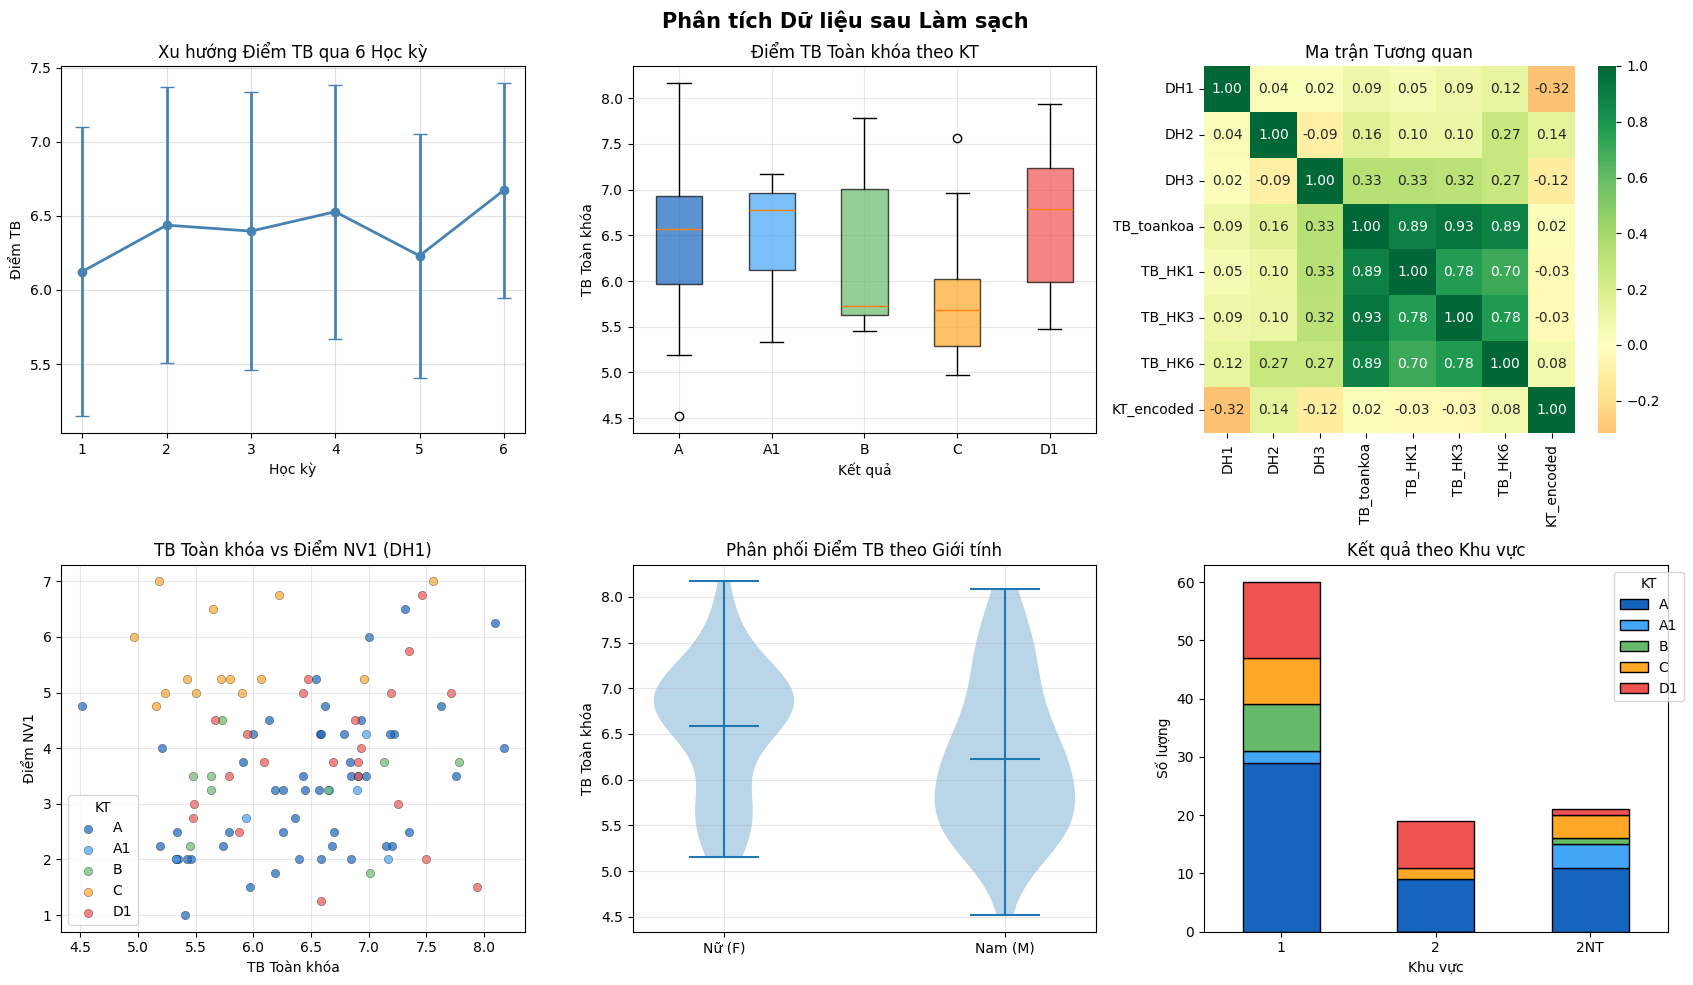

In [11]:
# ============================================================
# BƯỚC 11: BIỂU ĐỒ PHÂN TÍCH SAU LÀM SẠCH
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# 11.1 Xu hướng điểm TB qua 6 học kỳ
hk_means = [df_clean[f'TB_HK{i}'].mean() for i in range(1,7)]
hk_stds  = [df_clean[f'TB_HK{i}'].std()  for i in range(1,7)]
axes[0,0].errorbar(range(1,7), hk_means, yerr=hk_stds, marker='o',
                   color='steelblue', capsize=5, linewidth=2)
axes[0,0].set_title('Xu hướng Điểm TB qua 6 Học kỳ', fontsize=12)
axes[0,0].set_xlabel('Học kỳ'); axes[0,0].set_ylabel('Điểm TB')
axes[0,0].set_xticks(range(1,7)); axes[0,0].grid(True, alpha=0.4)

# 11.2 Điểm TB theo KT
kt_order = ['A','A1','B','C','D1']
colors_kt = ['#1565C0','#42A5F5','#66BB6A','#FFA726','#EF5350']
bp_data = [df_clean[df_clean['KT']==kt]['TB_toankoa'].values for kt in kt_order]
bp = axes[0,1].boxplot(bp_data, labels=kt_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_kt):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0,1].set_title('Điểm TB Toàn khóa theo KT', fontsize=12)
axes[0,1].set_xlabel('Kết quả'); axes[0,1].set_ylabel('TB Toàn khóa')
axes[0,1].grid(True, alpha=0.3)

# 11.3 Correlation heatmap điểm DH + TB
corr_cols = ['DH1','DH2','DH3','TB_toankoa',
             'TB_HK1','TB_HK3','TB_HK6','KT_encoded']
corr_matrix = df_clean[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0,2], cbar=True)
axes[0,2].set_title('Ma trận Tương quan', fontsize=12)

# 11.4 Scatter: TB_toankoa vs DH1
colors_map = {'A':'#1565C0','A1':'#42A5F5','B':'#66BB6A','C':'#FFA726','D1':'#EF5350'}
for kt, color in colors_map.items():
    mask = df_clean['KT'] == kt
    axes[1,0].scatter(df_clean.loc[mask,'TB_toankoa'],
                      df_clean.loc[mask,'DH1'],
                      c=color, label=kt, alpha=0.7, edgecolors='k', linewidths=0.3)
axes[1,0].set_title('TB Toàn khóa vs Điểm NV1 (DH1)', fontsize=12)
axes[1,0].set_xlabel('TB Toàn khóa'); axes[1,0].set_ylabel('Điểm NV1')
axes[1,0].legend(title='KT'); axes[1,0].grid(True, alpha=0.3)

# 11.5 Violin: điểm TB theo giới tính
gt_f = df_clean[df_clean['GT']=='F']['TB_toankoa']
gt_m = df_clean[df_clean['GT']=='M']['TB_toankoa']
axes[1,1].violinplot([gt_f, gt_m], positions=[1,2], showmeans=True)
axes[1,1].set_xticks([1,2]); axes[1,1].set_xticklabels(['Nữ (F)','Nam (M)'])
axes[1,1].set_title('Phân phối Điểm TB theo Giới tính', fontsize=12)
axes[1,1].set_ylabel('TB Toàn khóa'); axes[1,1].grid(True, alpha=0.3)

# 11.6 Stacked bar: KT phân theo KV
pivot = df_clean.groupby(['KV','KT']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, ax=axes[1,2],
           color=colors_kt[:len(pivot.columns)], edgecolor='black')
axes[1,2].set_title('Kết quả theo Khu vực', fontsize=12)
axes[1,2].set_xlabel('Khu vực'); axes[1,2].set_ylabel('Số lượng')
axes[1,2].legend(title='KT', bbox_to_anchor=(1.05,1))
axes[1,2].tick_params(axis='x', rotation=0)

plt.suptitle('Phân tích Dữ liệu sau Làm sạch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# BƯỚC 12: CHUYỂN ĐỔI SANG TENSOR (TensorFlow - Thực hành 2)
# ============================================================
# Lấy đặc trưng số để chuyển thành Tensor
feature_cols = score_cols + [f'TB_HK{i}' for i in range(1,7)] + \
               ['TB_toankoa','DH1','DH2','DH3','GT_encoded','KV_encoded']
label_col = 'KT_encoded'

X = df_clean[feature_cols].to_numpy().astype('float32')
y = df_clean[label_col].to_numpy().astype('int32')

# Tạo Tensor từ numpy array
X_tensor = tf.constant(X)
y_tensor = tf.constant(y)

print('=== BIỂU DIỄN TENSOR (Thực hành 2) ===')
print(f'X Tensor shape : {X_tensor.shape}')
print(f'X Tensor dtype : {X_tensor.dtype}')
print(f'y Tensor shape : {y_tensor.shape}')
print(f'y Tensor dtype : {y_tensor.dtype}')

print('\n=== CÁC PHÉP TOÁN TENSOR ===')
# Tính toán cơ bản
mean_tensor = tf.reduce_mean(X_tensor, axis=0)
std_tensor  = tf.math.reduce_std(X_tensor, axis=0)
min_tensor  = tf.reduce_min(X_tensor, axis=0)
max_tensor  = tf.reduce_max(X_tensor, axis=0)

print(f'Mean của TB_toankoa: {mean_tensor[-4].numpy():.4f}')
print(f'Std  của TB_toankoa: {std_tensor[-4].numpy():.4f}')
print(f'Min  của điểm (T1) : {min_tensor[0].numpy():.2f}')
print(f'Max  của điểm (T1) : {max_tensor[0].numpy():.2f}')

# Normalize (MinMax Scaling) bằng TensorFlow
X_min = tf.reduce_min(X_tensor, axis=0)
X_max = tf.reduce_max(X_tensor, axis=0)
X_norm = tf.divide(tf.subtract(X_tensor, X_min),
                   tf.subtract(X_max, X_min) + 1e-8)
print(f'\nX_norm shape: {X_norm.shape} | dtype: {X_norm.dtype}')
print(f'X_norm range: [{tf.reduce_min(X_norm).numpy():.4f}, {tf.reduce_max(X_norm).numpy():.4f}]')

=== BIỂU DIỄN TENSOR (Thực hành 2) ===
X Tensor shape : (100, 60)
X Tensor dtype : <dtype: 'float32'>
y Tensor shape : (100,)
y Tensor dtype : <dtype: 'int32'>

=== CÁC PHÉP TOÁN TENSOR ===
Mean của TB_toankoa: 4.2550
Std  của TB_toankoa: 1.0547
Min  của điểm (T1) : 2.40
Max  của điểm (T1) : 9.30

X_norm shape: (100, 60) | dtype: <dtype: 'float32'>
X_norm range: [0.0000, 1.0000]


In [13]:
# ============================================================
# BƯỚC 13: CÁC BÀI TẬP NUMPY LIÊN QUAN (mục 8 - tài liệu)
# ============================================================
score_arr = df_clean[score_cols].to_numpy()

print('--- BÀI 1: Kiểm tra tất cả điểm khác 0 ---')
print(f'  np.all > 0: {np.all(score_arr > 0)}')

print('\n--- BÀI 2: Kiểm tra tồn tại điểm khác 0 ---')
print(f'  np.any > 0: {np.any(score_arr > 0)}')

print('\n--- BÀI 3: So sánh 2 mảng (numpy.greater, less, equal) ---')
dh1_arr = df_clean['DH1'].to_numpy()
dh2_arr = df_clean['DH2'].to_numpy()
print(f'  DH1 > DH2: {np.sum(np.greater(dh1_arr, dh2_arr))} trường hợp')
print(f'  DH1 < DH2: {np.sum(np.less(dh1_arr, dh2_arr))} trường hợp')
print(f'  DH1 >= DH2: {np.sum(np.greater_equal(dh1_arr, dh2_arr))} trường hợp')

print('\n--- BÀI 13: Inner product (np.dot) điểm 2 học kỳ ---')
hk1 = df_clean[[f'{m}1' for m in ['T','L','H','S','V','X','D','N']]].mean().to_numpy()
hk2 = df_clean[[f'{m}2' for m in ['T','L','H','S','V','X','D','N']]].mean().to_numpy()
dot_product = np.dot(hk1, hk2)
print(f'  Dot product TB_HK1 vs TB_HK2: {dot_product:.4f}')

print('\n--- Pandas BÀI 27: Tìm điểm DH1 bị NaN ---')
null_dh = df_clean[df_clean['DH1'].isnull()][['STT','DH1','DH2','DH3','KT']]
print(f'  Không có NaN trong DH1 sau làm sạch' if len(null_dh)==0 else null_dh)

print('\n--- Pandas BÀI 28: Điểm DH1 trong khoảng (4, 7) ---')
between_mask = df_clean['DH1'].between(4, 7)
print(f'  Số hồ sơ DH1 trong (4,7): {between_mask.sum()}')
print(df_clean.loc[between_mask, ['STT','DH1','DH2','DH3','KT']].head(5))

--- BÀI 1: Kiểm tra tất cả điểm khác 0 ---
  np.all > 0: True

--- BÀI 2: Kiểm tra tồn tại điểm khác 0 ---
  np.any > 0: True

--- BÀI 3: So sánh 2 mảng (numpy.greater, less, equal) ---
  DH1 > DH2: 31 trường hợp
  DH1 < DH2: 62 trường hợp
  DH1 >= DH2: 38 trường hợp

--- BÀI 13: Inner product (np.dot) điểm 2 học kỳ ---
  Dot product TB_HK1 vs TB_HK2: 316.5177

--- Pandas BÀI 27: Tìm điểm DH1 bị NaN ---
  Không có NaN trong DH1 sau làm sạch

--- Pandas BÀI 28: Điểm DH1 trong khoảng (4, 7) ---
  Số hồ sơ DH1 trong (4,7): 43
   STT   DH1   DH2   DH3  KT
1    2  6.00  4.00  3.50   C
2    3  5.00  6.75  4.00   C
3    4  4.25  4.25  5.25  D1
4    5  4.25  4.50  5.00   A
6    7  6.50  6.75  5.25   C


In [14]:
# ============================================================
# BƯỚC 14: LƯU DỮ LIỆU ĐÃ LÀM SẠCH
# ============================================================
# Chọn các cột cần thiết để lưu
export_cols = ['STT'] + score_cols + \
              [f'TB_HK{i}' for i in range(1,7)] + \
              ['TB_toankoa','Diem_max','Diem_min',
               'GT','GT_encoded','KV','KV_encoded',
               'DH1','DH2','DH3','DH_tongdiem',
               'KT','KT_encoded']

df_export = df_clean[export_cols]
output_path = 'dulieuxettuyendaihoc_clean.csv'
df_export.to_csv(output_path, index=False)
print(f'Đã lưu file: {output_path}')
print(f'Shape: {df_export.shape}')
print(df_export.head(3))

# Download file
from google.colab import files
files.download(output_path)

Đã lưu file: dulieuxettuyendaihoc_clean.csv
Shape: (100, 68)
   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...  GT  GT_encoded   KV  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...   F           0  2NT   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...   M           1    1   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...   M           1    1   

   KV_encoded   DH1   DH2  DH3  DH_tongdiem  KT  KT_encoded  
0           3  3.25  3.25  4.5        11.00  A1           3  
1           1  6.00  4.00  3.5        13.50   C           1  
2           1  5.00  6.75  4.0        15.75   C           1  

[3 rows x 68 columns]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# ============================================================
# BƯỚC 15: TỔNG KẾT QUY TRÌNH LÀM SẠCH
# ============================================================
print('='*60)
print('   TÓM TẮT QUY TRÌNH LÀM SẠCH DỮ LIỆU')
print('='*60)
print(f'Dataset gốc   : {df_raw.shape[0]} hồ sơ × {df_raw.shape[1]} cột')
print(f'Dataset sạch  : {df_export.shape[0]} hồ sơ × {df_export.shape[1]} cột')
print()
print('CÁC BƯỚC ĐÃ THỰC HIỆN:')
print('  [1] Xóa cột DT (97% thiếu)')
print('  [2] Kiểm tra điểm: không có NaN, không ngoài [0,10]')
print('  [3] Encode GT: F→0, M→1')
print('  [4] Encode KV: 1→1, 2→2, 2NT→3')
print('  [5] Encode KT: A→4, A1→3, B→2, C→1, D1→0')
print('  [6] Thêm TB_HK1..HK6, TB_toankoa, Diem_max/min, DH_tongdiem')
print()
print('THƯ VIỆN SỬ DỤNG:')
print(f'  Numpy  {np.__version__} — array, nanmin/max, all/any, dot, greater/less')
print(f'  Pandas {pd.__version__} — read_csv, groupby, fillna, isnull, between, drop')
print(f'  TF     {tf.__version__} — tf.constant, reduce_mean/min/max, math ops')
print('='*60)

   TÓM TẮT QUY TRÌNH LÀM SẠCH DỮ LIỆU
Dataset gốc   : 100 hồ sơ × 56 cột
Dataset sạch  : 100 hồ sơ × 68 cột

CÁC BƯỚC ĐÃ THỰC HIỆN:
  [1] Xóa cột DT (97% thiếu)
  [2] Kiểm tra điểm: không có NaN, không ngoài [0,10]
  [3] Encode GT: F→0, M→1
  [4] Encode KV: 1→1, 2→2, 2NT→3
  [5] Encode KT: A→4, A1→3, B→2, C→1, D1→0
  [6] Thêm TB_HK1..HK6, TB_toankoa, Diem_max/min, DH_tongdiem

THƯ VIỆN SỬ DỤNG:
  Numpy  2.0.2 — array, nanmin/max, all/any, dot, greater/less
  Pandas 2.2.2 — read_csv, groupby, fillna, isnull, between, drop
  TF     2.20.0 — tf.constant, reduce_mean/min/max, math ops
